# 02 Exploratory analysis and preprocessing

The analysis describes electrical loads, telemetry quality, target distributions and differences between data splits. Numerical nonconvergence and simulated missing measurements are treated separately. Standardization and other fitted transformations use training observations only; test outcomes do not determine feature selection.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
from scipy.stats import ks_2samp, skew
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

training = indices["train"]
features = pd.DataFrame(bundle.tabular, columns=bundle.feature_names)
analysis = features[
    [
        "total_p_kw",
        "slack_vm",
        "missing_rate",
        "mean_age",
        "depth_max",
        "proxy_vmin",
        "proxy_loss_kw",
    ]
].copy()
analysis["vmin"] = metadata.target_vmin.where(metadata.converged.eq(1))
analysis["loss_kw"] = metadata.target_loss_kw.where(metadata.converged.eq(1))

## Descriptive statistics

Location, dispersion and tail behavior are summarized for the electrical and telemetry variables.

In [3]:
description = (
    analysis.agg(["count", "mean", "std", "min", "median", "max"])
    .T.reset_index()
    .rename(columns={"index": "variable", "count": "n"})
)
description["q05"] = analysis.quantile(0.05).to_numpy()
description["q95"] = analysis.quantile(0.95).to_numpy()
description["unavailable_n"] = analysis.isna().sum().to_numpy()
show_table(
    description,
    ["variable", "n"],
    {
        "Location and dispersion": ["mean", "median", "std"],
        "Range and tails": ["min", "q05", "q95", "max"],
        "Unavailable physical targets": ["unavailable_n"],
    },
    TABLES / "02_descriptive.csv",
)

Loss dispersion must be interpreted alongside the physical convergence rule. Invalid physical targets are missing in this analysis by design; they are not measurement gaps to be imputed. Log-loss learning is retained for its nonnegative, right-skewed scale.

## Target and telemetry distributions

Distribution shapes are compared across the data splits.

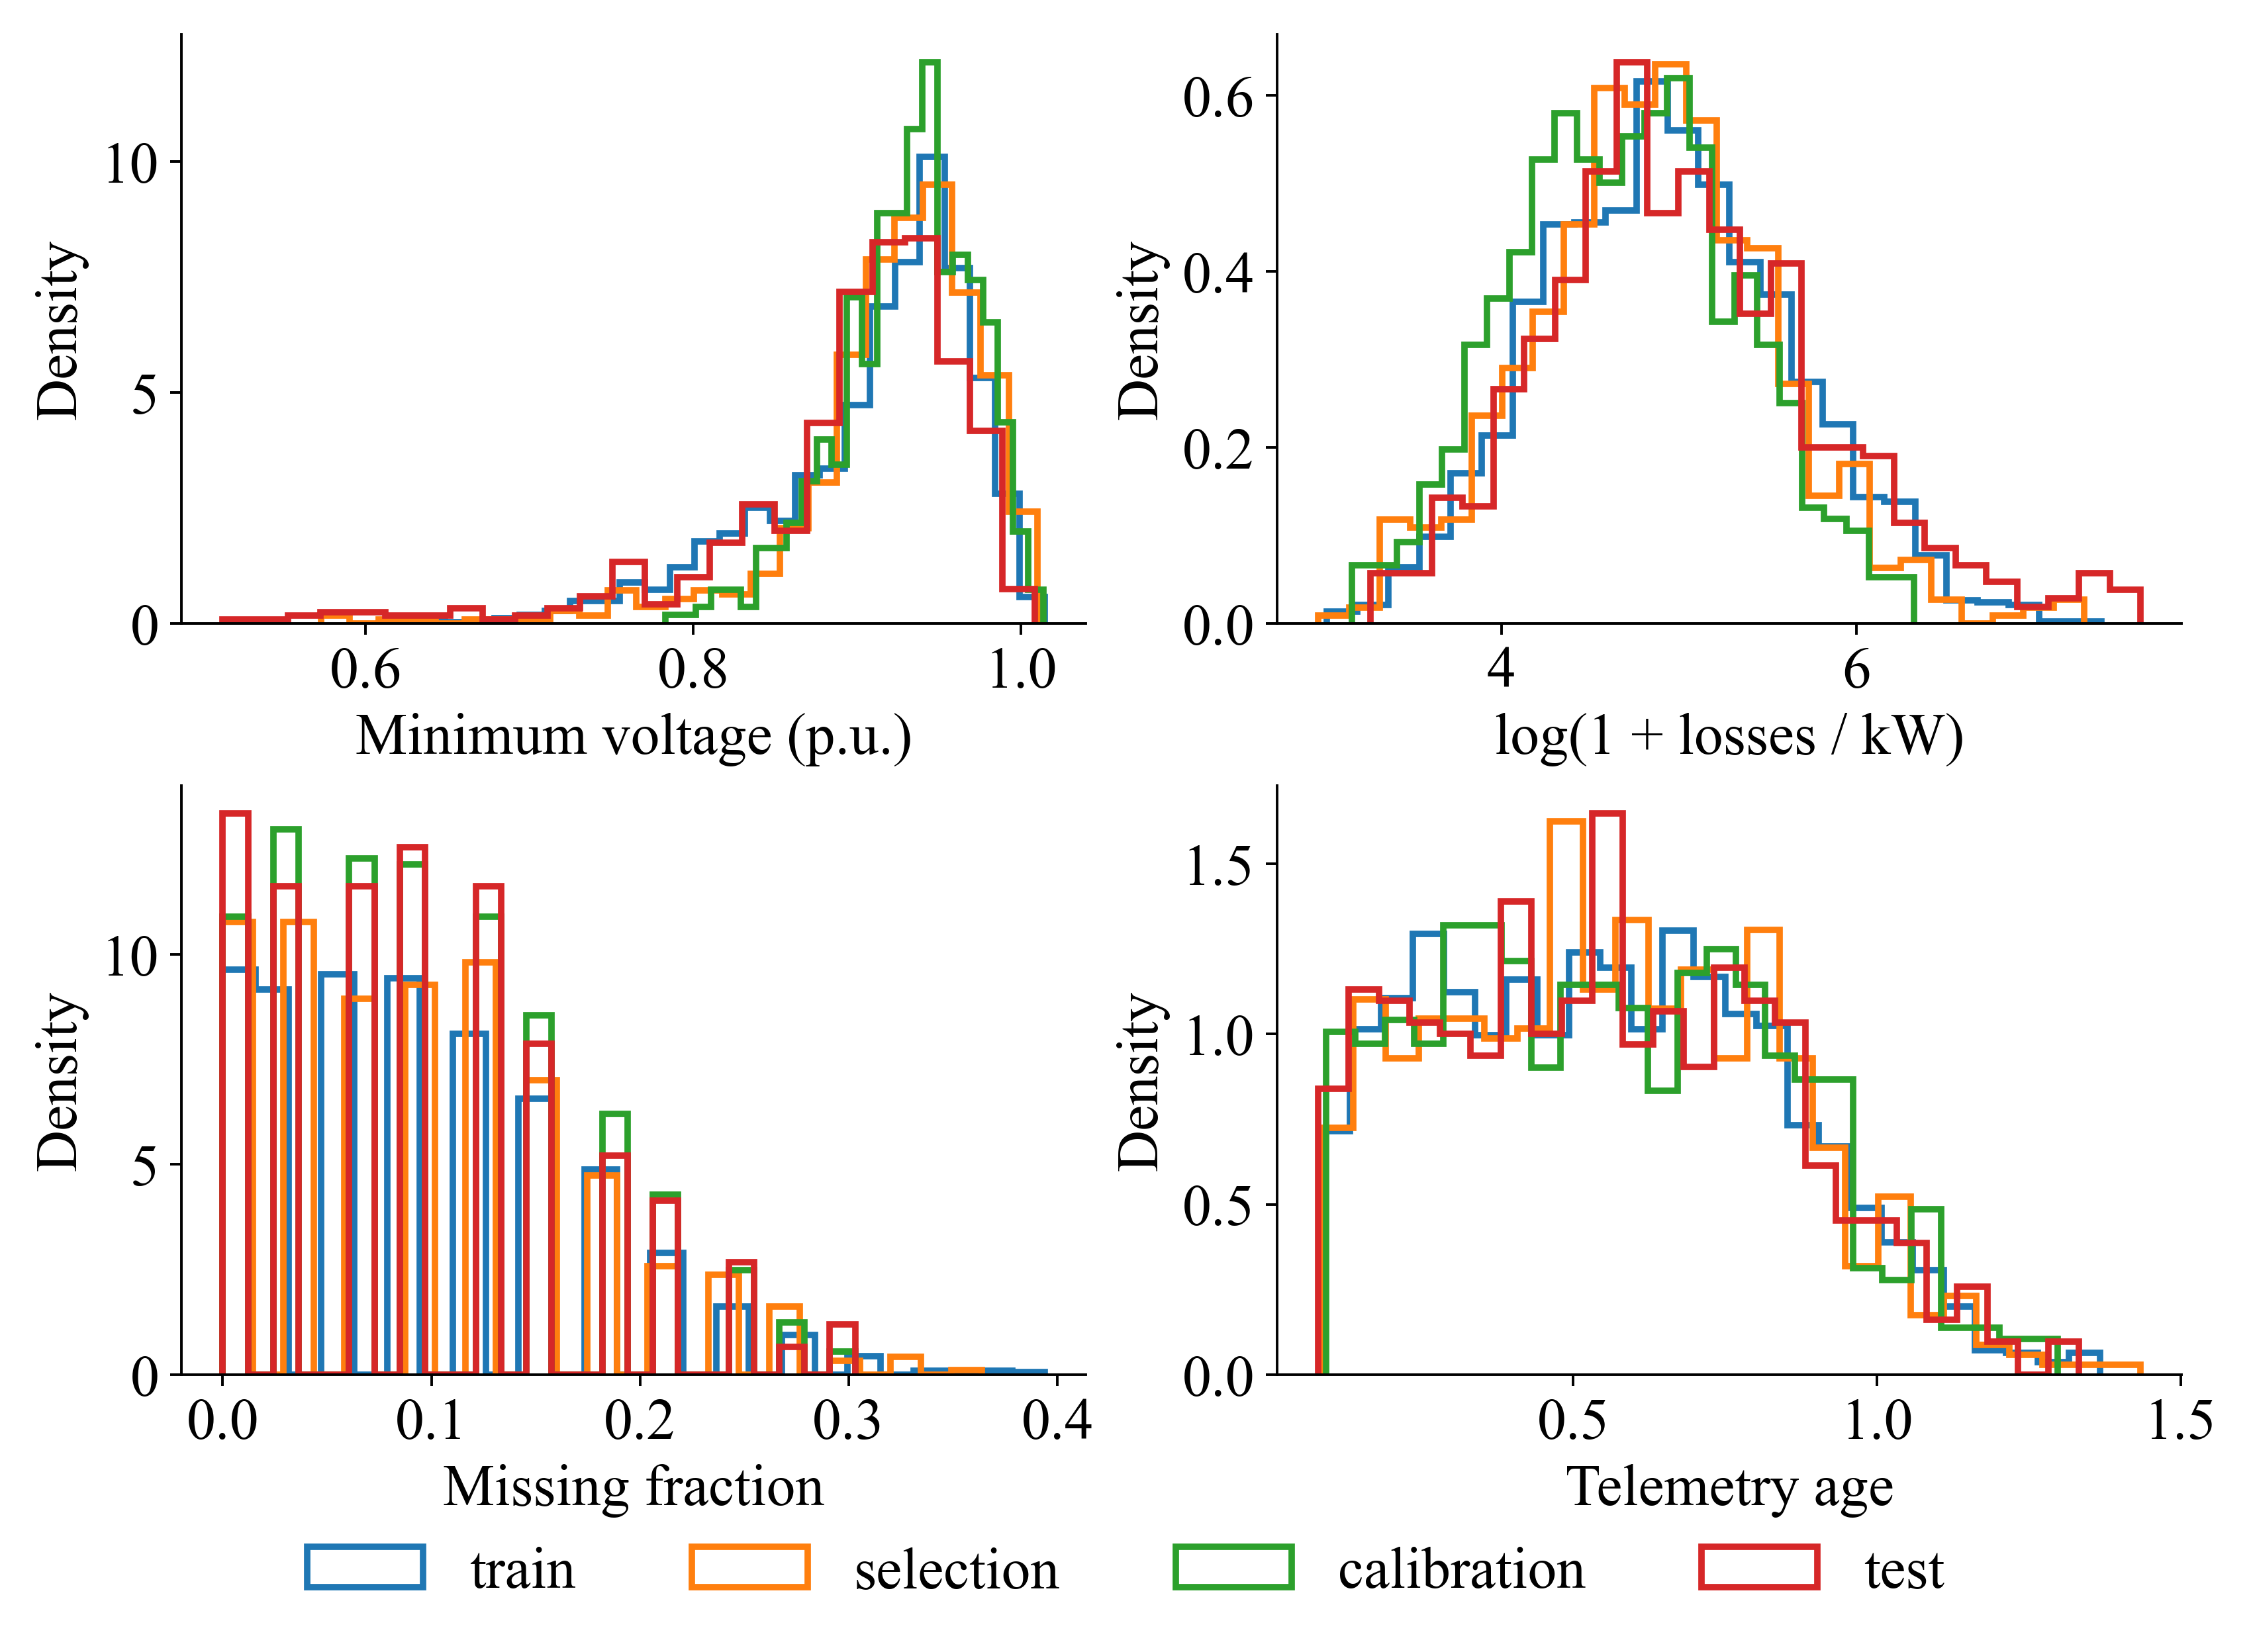

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.0), layout="constrained")
variables = [
    ("vmin", "Minimum voltage (p.u.)"),
    ("loss_kw", "log(1 + losses / kW)"),
    ("missing_rate", "Missing fraction"),
    ("mean_age", "Telemetry age"),
]
for axis, (column, label) in zip(axes.flat, variables):
    for split in ["train", "selection", "calibration", "test"]:
        values = analysis.loc[metadata.split.eq(split), column].dropna().to_numpy()
        if column == "loss_kw":
            values = np.log1p(values)
        axis.hist(values, bins=25, histtype="step", density=True, linewidth=2, label=split)
    axis.set(xlabel=label, ylabel="Density")
legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=4, frameon=False)
save_figure(fig, FIGURES / "2_Target_and_telemetry_distributions.png")
plt.show()
analysis.assign(split=metadata.split).to_csv(TABLES / "02_distribution_source.csv", index=False)

The panels distinguish topology-induced target shift from measurement degradation. These are distributions of independent simulated states; the hour/day covariates do not form a chronological operating trajectory.

## Monotonic and nonlinear dependence

Training-set associations characterize dependence between physical proxies, telemetry and outcomes.

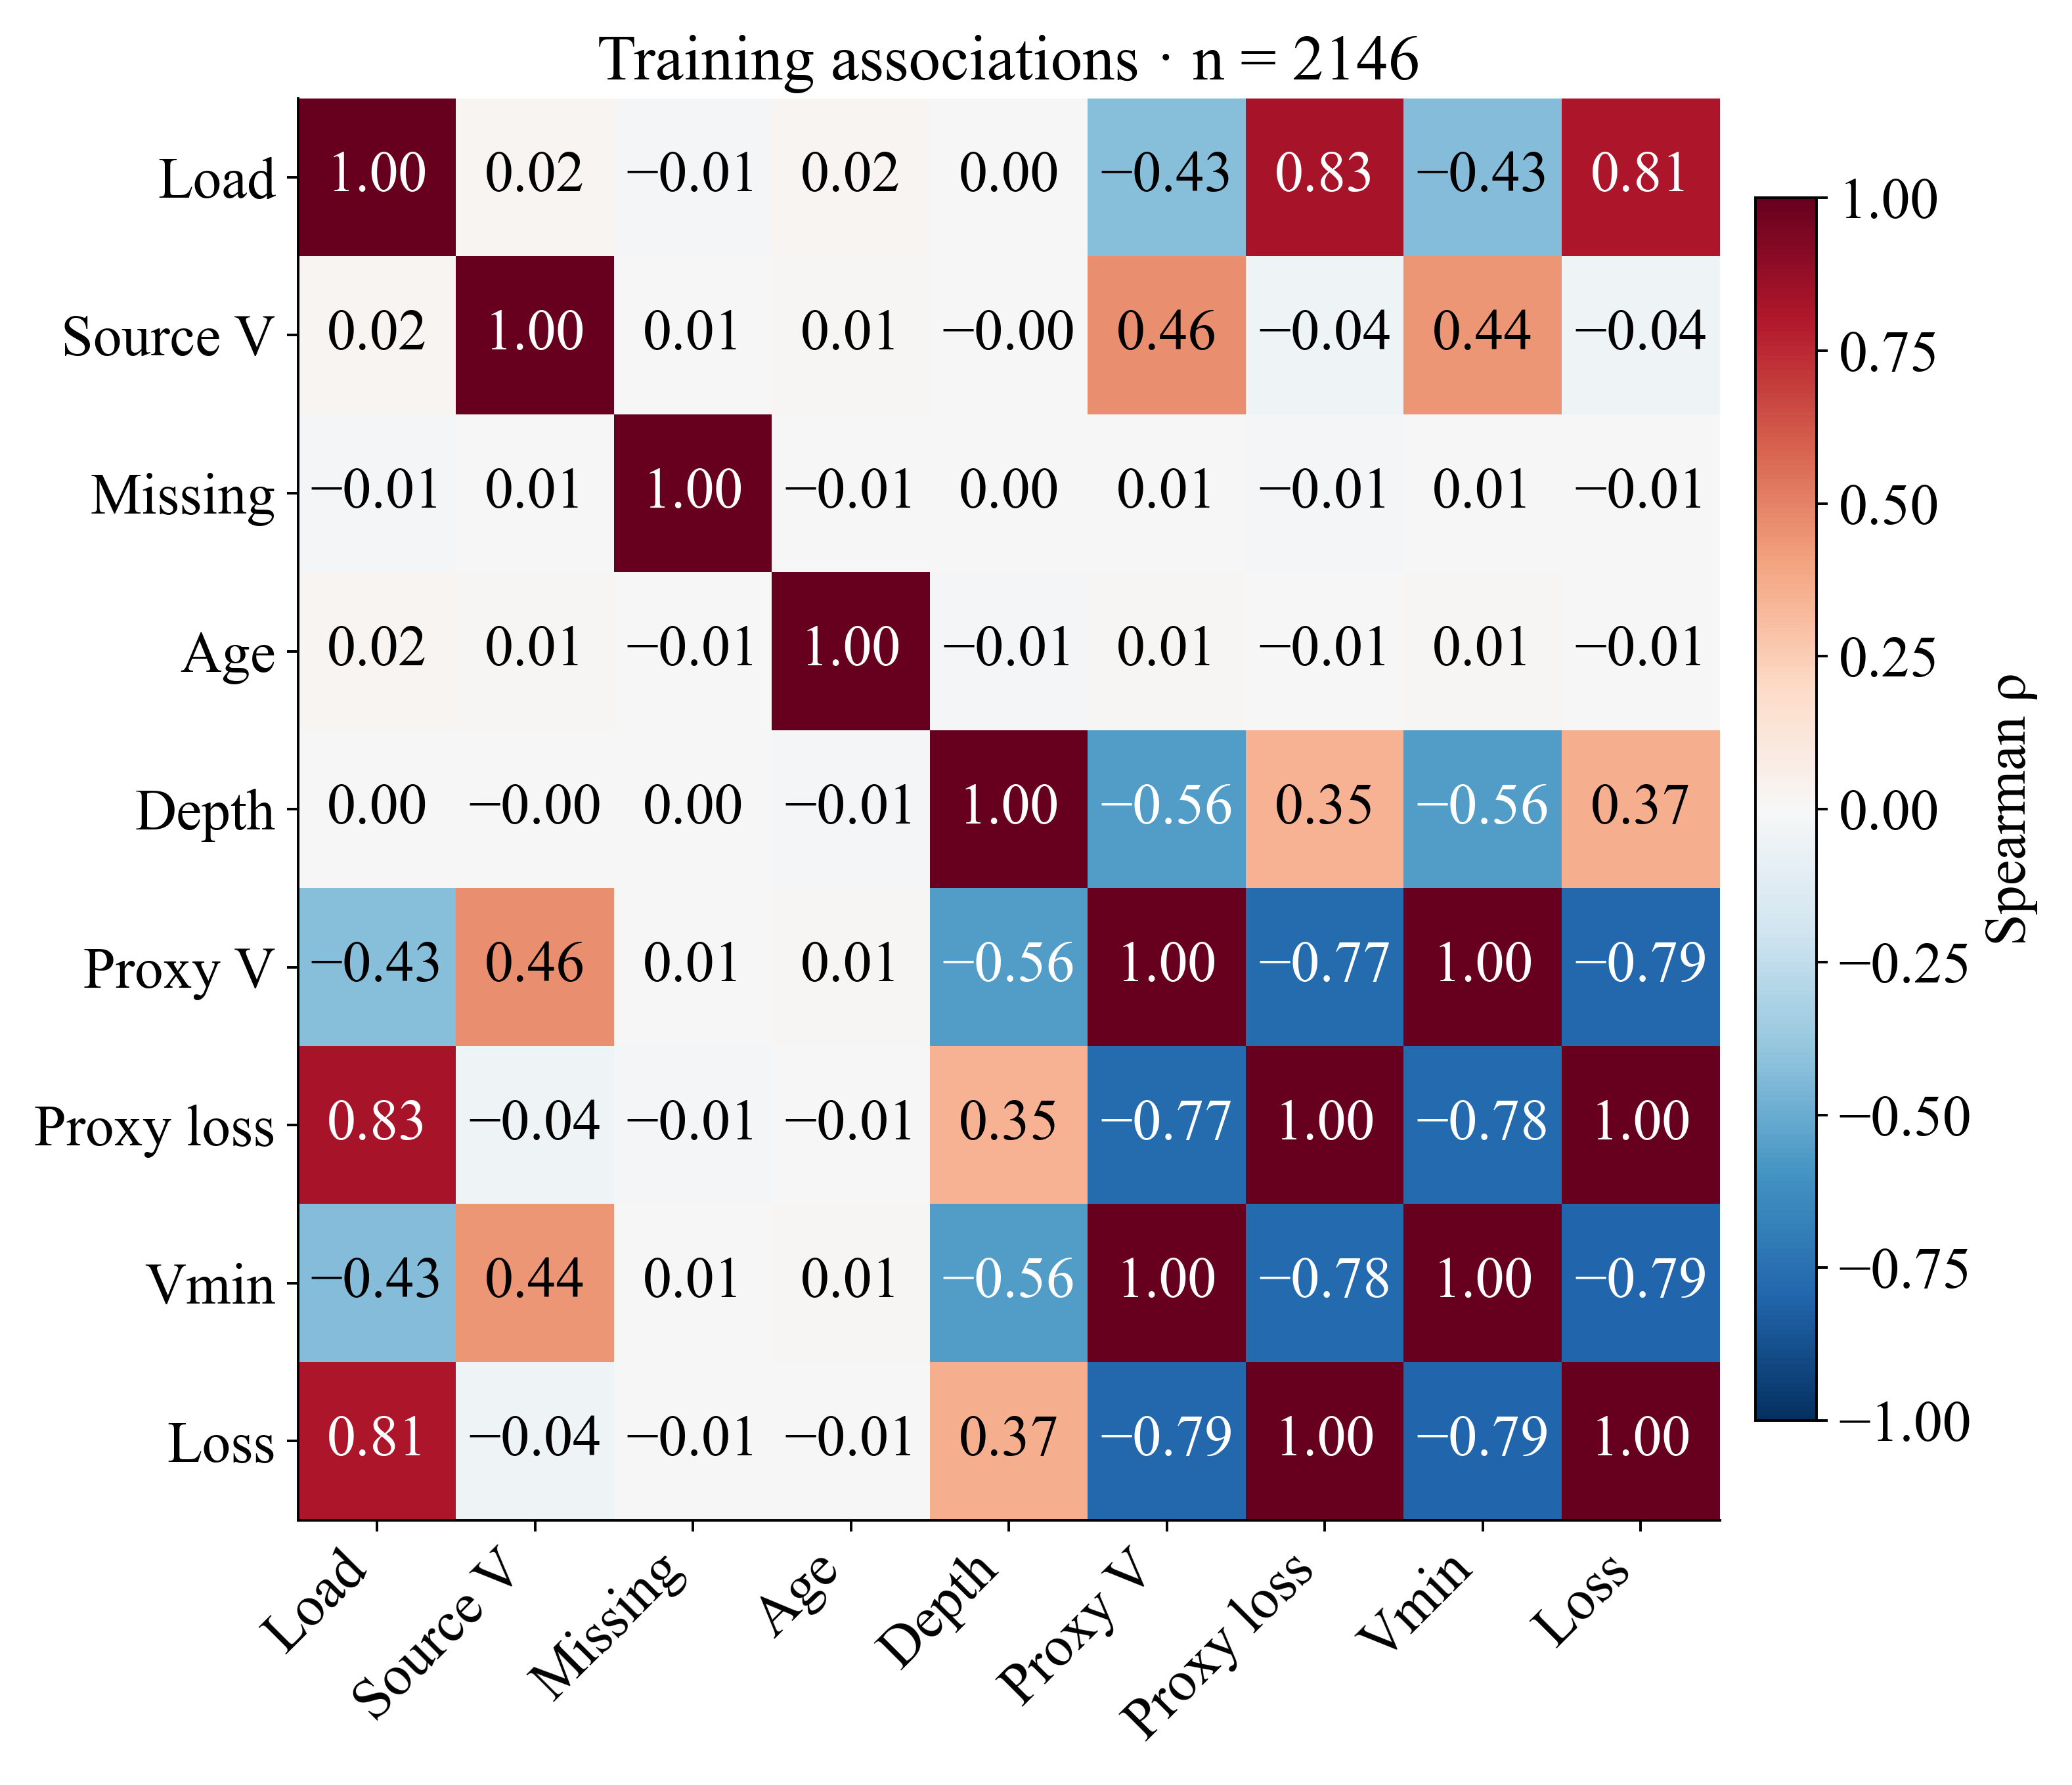

In [5]:
training_analysis = analysis.iloc[training]
correlation = training_analysis.corr(method="spearman")
labels = [
    "Load",
    "Source V",
    "Missing",
    "Age",
    "Depth",
    "Proxy V",
    "Proxy loss",
    "Vmin",
    "Loss",
]
fig, axis = plt.subplots(figsize=(8.8, 7.8), layout="constrained")
image = axis.imshow(correlation, vmin=-1, vmax=1, cmap="RdBu_r")
axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
axis.set_yticks(range(len(labels)), labels)
for row in range(len(labels)):
    for column in range(len(labels)):
        value = correlation.iloc[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=18,
            color="white" if abs(value) > 0.55 else "black",
        )
fig.colorbar(image, ax=axis, shrink=0.78, fraction=0.046, pad=0.025, label="Spearman ρ")
axis.set_title(f"Training associations · n = {len(training)}")
save_figure(fig, FIGURES / "3_Training_rank_associations.png")
plt.show()
correlation.to_csv(TABLES / "02_spearman_source.csv")

Physical proxies and outcomes share information by construction, supporting correction of an approximation. Correlation is not evidence of causal importance; aggregate and node features can be redundant without leaking targets.

## Nonlinear information and collinearity

Mutual information and collinearity diagnostics characterize the compact physical feature block.

In [6]:
columns = ["total_p_kw", "slack_vm", "missing_rate", "mean_age", "depth_max"]
training_features = features.iloc[training][columns]
standardized = StandardScaler().fit_transform(training_features)
information = mutual_info_regression(
    training_features, bundle.targets[training, 0], random_state=SEED
)
rows = []
for column, name in enumerate(columns):
    other = np.delete(standardized, column, axis=1)
    score = (
        LinearRegression()
        .fit(other, standardized[:, column])
        .score(other, standardized[:, column])
    )
    rows.append(
        dict(
            variable=name,
            split="train",
            n=len(training),
            vif=1 / max(1 - score, 1e-12),
            mutual_information_vmin=information[column],
        )
    )
redundancy = pd.DataFrame(rows)
show_table(
    redundancy,
    ["variable", "split", "n"],
    {"Redundancy and nonlinear association": ["vif", "mutual_information_vmin"]},
    TABLES / "02_redundancy.csv",
)

variable,split,n,vif,mutual_information_vmin
total_p_kw,train,2146,1.0006,0.1884
slack_vm,train,2146,1.0005,0.2036
missing_rate,train,2146,1.0001,0.0000
mean_age,train,2146,1.0004,0.0018
depth_max,train,2146,1.0001,0.3569


The compact standardized feature block has condition number 1.03. VIF and mutual information are descriptive training-only diagnostics; no variables are removed by inspecting test outcomes.

## Tail observations and measurement absence

Training-derived tail rules and telemetry availability describe unusual operating conditions.

In [7]:
rows = []
for column in ["total_p_kw", "proxy_loss_kw", "mean_age"]:
    reference = features.iloc[training][column]
    median = reference.median()
    scale = 1.4826 * np.median(np.abs(reference - median))
    for split in ["train", "test", "external"]:
        values = features.iloc[indices[split]][column]
        rows.append(
            dict(
                variable=column,
                split=split,
                n=len(values),
                robust_tail_fraction=float(
                    (np.abs(values - median) / max(scale, 1e-9) > 3.5).mean()
                ),
            )
        )
tails = pd.DataFrame(rows)
show_table(
    tails,
    ["variable", "split", "n"],
    {"Training-referenced outliers": ["robust_tail_fraction"]},
    TABLES / "02_tails.csv",
)

variable,split,n,robust_tail_fraction
total_p_kw,train,2146,0.0000
total_p_kw,test,618,0.0000
total_p_kw,external,800,0.0000
proxy_loss_kw,train,2146,0.0340
proxy_loss_kw,test,618,0.0955
proxy_loss_kw,external,800,0.0013
mean_age,train,2146,0.0000
mean_age,test,618,0.0000
mean_age,external,800,0.0000


Tail flags retain all observations. Severe electrical conditions and larger external-network loads are relevant operating regimes; removing them would change the research question.

## Joint missingness and age

Co-occurring missing measurements and telemetry age are examined across primary-feeder nodes.

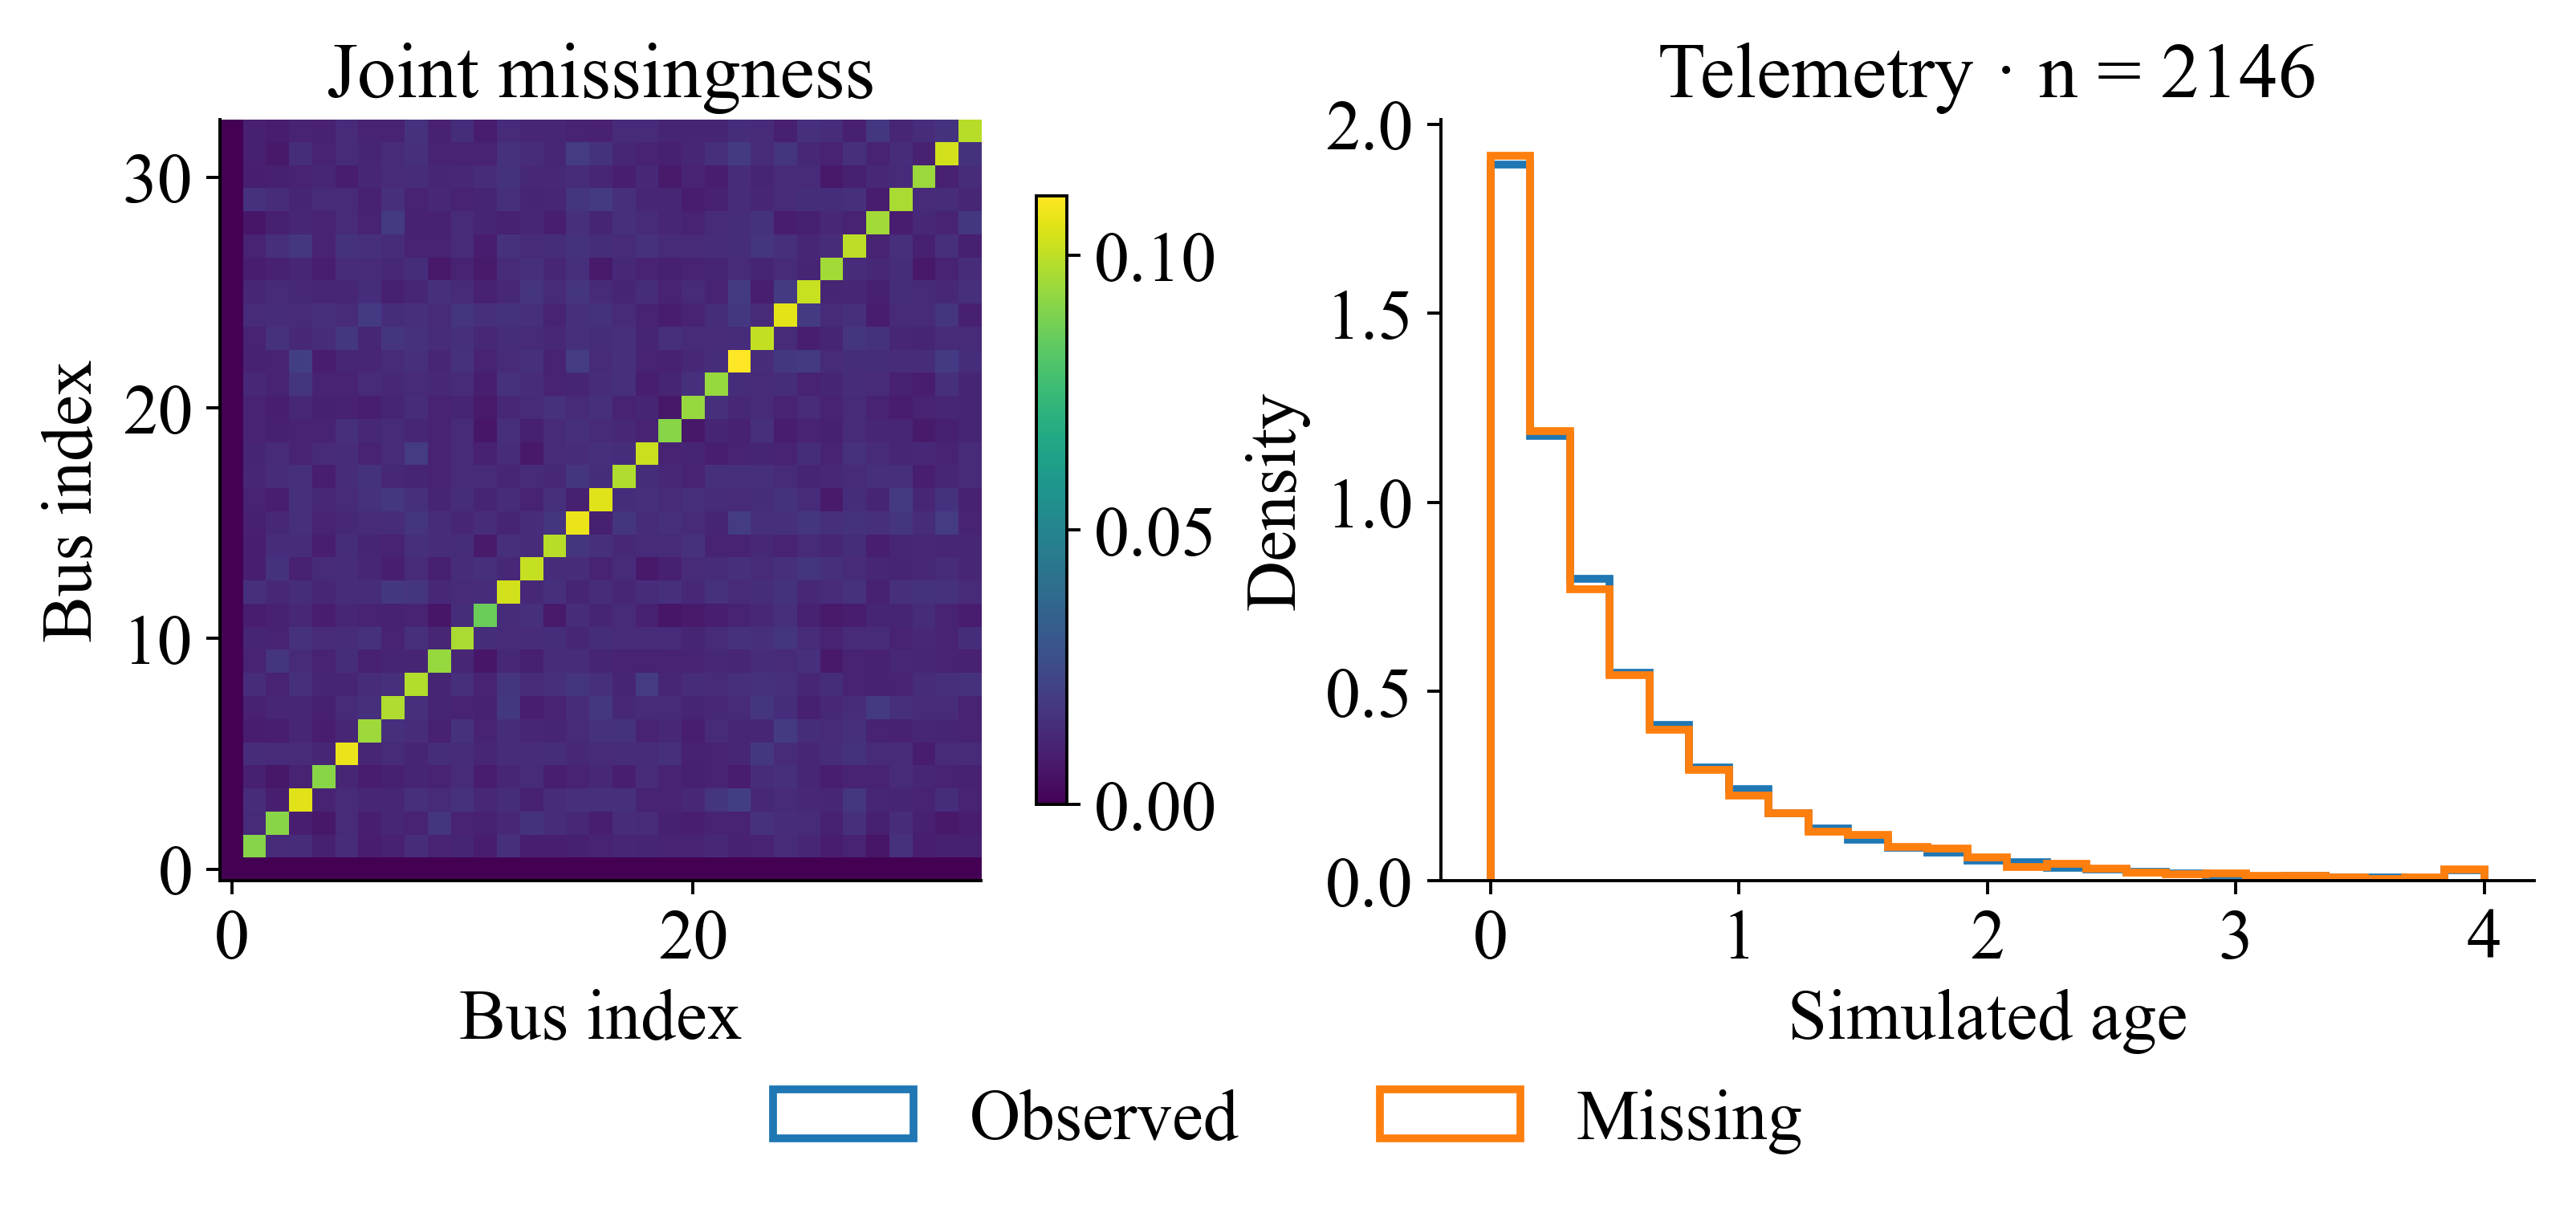

In [8]:
observed = bundle.node_features[training, :33, 6]
age = bundle.node_features[training, :33, 7] * 4
co_missing = (1 - observed).T @ (1 - observed) / len(training)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), layout="constrained")
image = axes[0].imshow(co_missing, cmap="viridis", origin="lower")
axes[0].set(xlabel="Bus index", ylabel="Bus index", title="Joint missingness")
fig.colorbar(image, ax=axes[0], shrink=0.8)
axes[1].hist(
    age[observed == 1], bins=25, density=True, histtype="step", linewidth=2, label="Observed"
)
axes[1].hist(
    age[observed == 0], bins=25, density=True, histtype="step", linewidth=2, label="Missing"
)
axes[1].set(xlabel="Simulated age", ylabel="Density", title=f"Telemetry · n = {len(training)}")
legend_handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
save_figure(fig, FIGURES / "4_Missingness_and_telemetry_age.png")
plt.show()
pd.DataFrame(co_missing).to_csv(TABLES / "02_missingness_source.csv", index=False)

The source bus is always observed, while other buses undergo simulated missingness. The mask and age channels preserve this information after deterministic reference-load imputation. The simulation does not establish the missingness mechanism of a real SCADA system.

## Distribution shift

Marginal shifts are compared between training, test and external data.

In [9]:
rows = []
for split in ["test", "external"]:
    for column in ["total_p_kw", "slack_vm", "missing_rate", "mean_age", "depth_max"]:
        first = features.iloc[training][column].to_numpy()
        second = features.iloc[indices[split]][column].to_numpy()
        statistic = ks_2samp(first, second).statistic
        rows.append(
            dict(
                variable=column,
                comparison=f"train vs {split}",
                n=len(second),
                ks_distance=statistic,
                standardized_mean_shift=(second.mean() - first.mean()) / max(first.std(), 1e-9),
            )
        )
shift = pd.DataFrame(rows)
show_table(
    shift,
    ["variable", "comparison", "n"],
    {"Marginal shift magnitude": ["ks_distance", "standardized_mean_shift"]},
    TABLES / "02_shift.csv",
)

variable,comparison,n,ks_distance,standardized_mean_shift
total_p_kw,train vs test,618,0.0308,-0.0173
slack_vm,train vs test,618,0.0336,0.0284
missing_rate,train vs test,618,0.0135,-0.0110
mean_age,train vs test,618,0.0215,-0.0087
depth_max,train vs test,618,0.2333,0.1579
total_p_kw,train vs external,800,0.0368,0.0444
slack_vm,train vs external,800,0.0780,0.0314
missing_rate,train vs external,800,0.0938,0.0354
mean_age,train vs external,800,0.0336,-0.0221
depth_max,train vs external,800,1.0000,2.1453


KS distances quantify marginal discrepancies. Row-level KS p-values are deliberately omitted because scenarios share electrical topologies. A single external network cannot establish population-level cross-network generalization.

## Fold-local preprocessing

Imputation and scaling retain measurement information while fitting statistical transformations within training folds.

In [10]:
from src.gridstudy import impute_observations

reference = case_reference = np.array([0.0, 100.0, 80.0])
measured = np.array([0.0, 120.0, np.nan])
imputed = impute_observations(measured, reference)
assert np.allclose(imputed, [0.0, 120.0, 96.0])
rows = []
for fold in range(3):
    fit = training[fold_id[training] != fold]
    held = training[fold_id[training] == fold]
    scaler = StandardScaler().fit(bundle.tabular[fit])
    transformed = scaler.transform(bundle.tabular[held])
    assert np.isfinite(transformed).all()
    rows.append(
        dict(
            fold=fold,
            split="training OOF",
            n=len(held),
            fit_n=len(fit),
            tabular_features=transformed.shape[1],
            node_channels=bundle.node_features.shape[2],
            max_abs_training_mean=float(
                np.abs(scaler.transform(bundle.tabular[fit]).mean(axis=0)).max()
            ),
        )
    )
preprocessing = pd.DataFrame(rows)
show_table(
    preprocessing,
    ["fold", "split", "n"],
    {
        "Fitted representation": [
            "fit_n",
            "tabular_features",
            "node_channels",
            "max_abs_training_mean",
        ]
    },
    TABLES / "02_preprocessing.csv",
    digits=6,
)

fold,split,n,fit_n,tabular_features,node_channels,max_abs_training_mean
0,training OOF,715,1431,21,10,0.000001
1,training OOF,714,1432,21,10,0.000000
2,training OOF,717,1429,21,10,0.000001


Only fold-training rows determine standardization. Missing loads use known benchmark reference loads and contemporaneous observed totals, never target values. Feasibility imbalance is handled by training-only class weighting where supported; no synthetic oversampling or test-fitted feature selection is used.

## Preprocessing summary

Statistical transformations are fitted within training folds. Telemetry masks and age channels retain measurement-quality information after imputation. Numerical failures, extreme regimes and distribution shifts remain explicit in evaluation.